**Greedy SOSP Update testing**

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D


# incrementing node sizes twice the previous
NODE_SIZES = [4, 8, 16, 32, 64, 128, 256, 512, 1024]
EDGE_PROBS = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]  # edge probablity for nodes

REPEAT = 10  # repetation of 10

from greedy_sosp_update_new import Greedy_SOSP_Update
from utils.generate_graph import generate_graph


results = []  # for storing ablation results
# total no of running exp.
total_runs = len(NODE_SIZES)*len(EDGE_PROBS) * REPEAT

with tqdm(total=total_runs) as pbar:
    for n in NODE_SIZES:
        for prob in EDGE_PROBS:
            for r in range(REPEAT):
                # for each node having all the prob generate graph
                G = generate_graph(n, prob)

                # for each node and edge probablity, checking performance of greedy_sosp_update
                start = time.perf_counter()  # starting runtime
                Greedy_SOSP_Update(G)  # greedy sosp update algorithm running
                end = time.perf_counter()  # ending runtime
                runtime = end - start  # total runtime by algo

                # storing results
                results.append({
                    "nodes": n,
                    "edge_prob": prob,
                    "runtime": runtime
                })

                pbar.update(1)  # for updating tqdm


100%|██████████| 540/540 [35:14<00:00,  3.92s/it]  


In [2]:
# Total runtime taken 35.14 mins
# Saving results
df = pd.DataFrame(results)
df.to_csv('GSOSPNew_AS.csv', index=False)

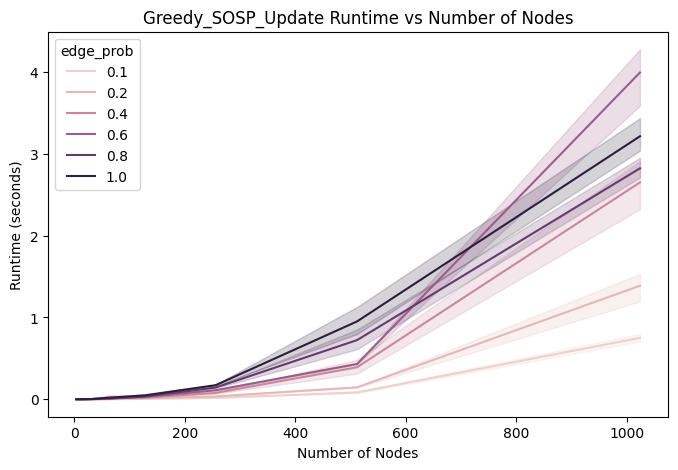

In [3]:
# run time vs nodes plot
plt.figure(figsize=(8, 5))

sns.lineplot(data=df,
             x="nodes",
             y="runtime",
             hue="edge_prob",
             estimator="mean")

plt.title("Greedy_SOSP_Update Runtime vs Number of Nodes")
plt.xlabel("Number of Nodes")
plt.ylabel("Runtime (seconds)")

plt.show()


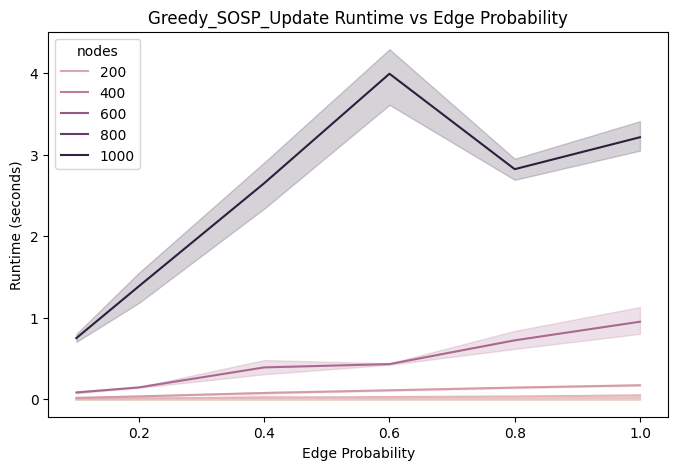

In [4]:
# runtime vs edge probablity
plt.figure(figsize=(8, 5))

sns.lineplot(data=df,
             x="edge_prob",
             y="runtime",
             hue="nodes",
             estimator="mean")

plt.title("Greedy_SOSP_Update Runtime vs Edge Probability")
plt.xlabel("Edge Probability")
plt.ylabel("Runtime (seconds)")

plt.show()


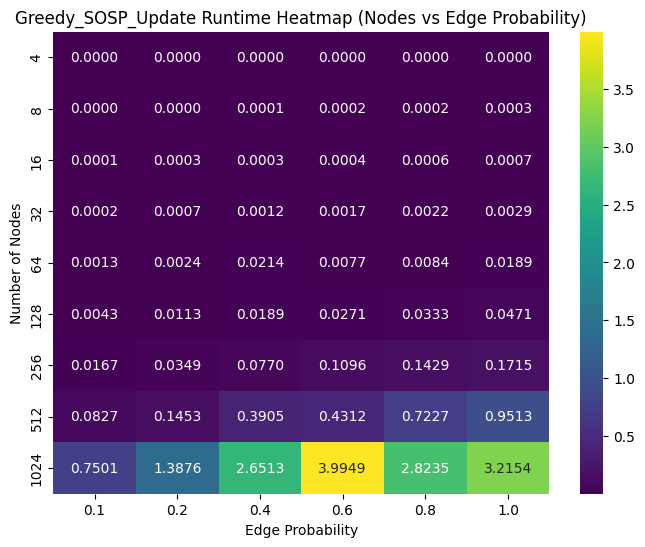

In [5]:
# heatmap n vs e
pivot = df.pivot_table(values="runtime",
                       index="nodes",
                       columns="edge_prob",
                       aggfunc=np.mean)

plt.figure(figsize=(8, 6))

sns.heatmap(pivot,
            annot=True,
            fmt=".4f",
            cmap="viridis")

plt.title("Greedy_SOSP_Update Runtime Heatmap (Nodes vs Edge Probability)")
plt.xlabel("Edge Probability")
plt.ylabel("Number of Nodes")

plt.show()


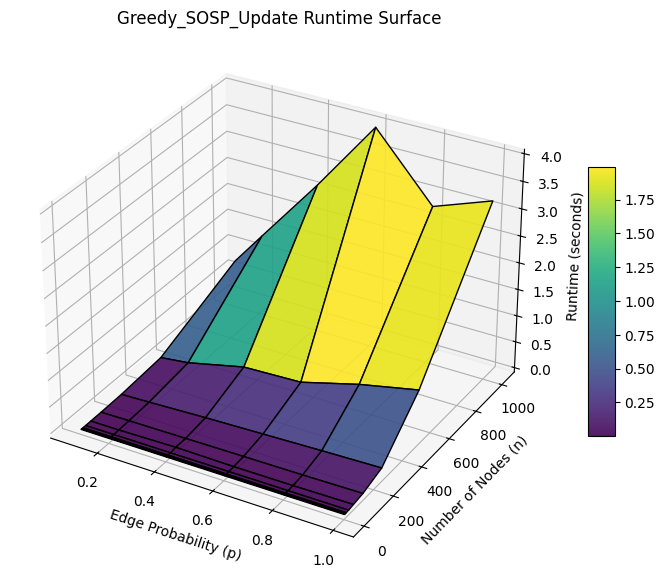

In [6]:

# a 3D representation of nodes, edge probablity and runtime

pivot = df.pivot_table(
    values="runtime",
    index="nodes",
    columns="edge_prob",
    aggfunc=np.mean
)

nodes = pivot.index.values
edge_probs = pivot.columns.values

X, Y = np.meshgrid(edge_probs, nodes)
Z = pivot.values

# X -> edge probablity
# Y -> node counts
# Z -> runtime


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(
    X, Y, Z,
    cmap='viridis',
    edgecolor='k',
    alpha=0.9
)

ax.set_xlabel("Edge Probability (p)")
ax.set_ylabel("Number of Nodes (n)")
ax.set_zlabel("Runtime (seconds)")
ax.set_title("Greedy_SOSP_Update Runtime Surface")
fig.colorbar(surface, shrink=0.5, aspect=10)
# plt.savefig("runtime_surface_plot.png", dpi=300, bbox_inches="tight")

plt.show()

# Greedy_SOSP_Update Runtime Surface interpretation
# surface rises as nodes increases
# surface rises as edge probablity increases
# highest peak occurs as p = 1.0 and n = 1024


In [7]:
from utils.generate_graph import generate_graph
from robust_mosp_update_new import Robust_MOSP_Update

results = []
total_runs = len(NODE_SIZES) * len(EDGE_PROBS) * \
    REPEAT  # total number of running time

with tqdm(total=total_runs) as pbar:
    for n in NODE_SIZES:
        for p in EDGE_PROBS:
            for r in range(REPEAT):
                G = generate_graph(n, p)
                start = time.perf_counter()
                Robust_MOSP_Update(G)  # running robust_mosp_update algo
                end = time.perf_counter()
                runtime = end - start  # runtime for running algo

                results.append({
                    "nodes": n,
                    "edge_prob": p,
                    "runtime": runtime
                })

                pbar.update(1)


100%|██████████| 540/540 [48:07<00:00,  5.35s/it] 


In [8]:
# took total time of 48.8 min

# DON'T RUN THIS AGAIN
df2 = pd.DataFrame(results)
df2.to_csv("RMOSPNew_AS.csv", index=False)

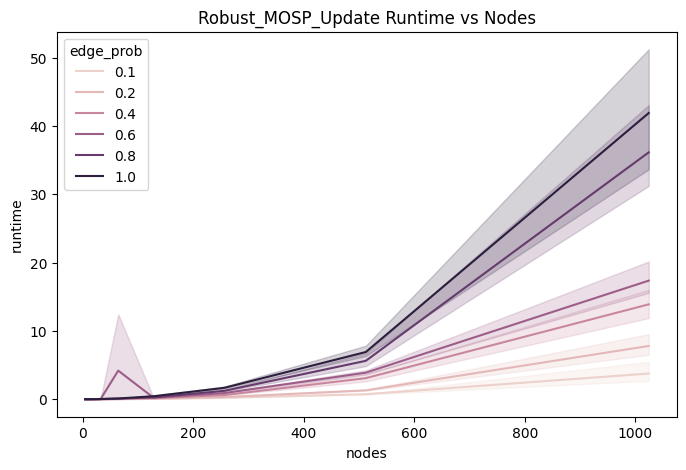

In [9]:
# plotting runtime vs nodes
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=df2,
    x="nodes",
    y="runtime",
    hue="edge_prob",
    estimator="mean"
)

plt.title("Robust_MOSP_Update Runtime vs Nodes")
plt.show()

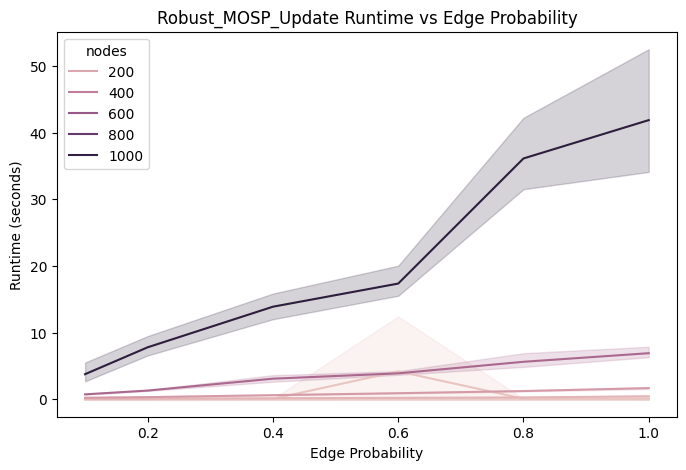

In [10]:
# Runtime vs Edge probablity
plt.figure(figsize=(8, 5))

sns.lineplot(data=df2,
             x="edge_prob",
             y="runtime",
             hue="nodes",
             estimator="mean")

plt.title("Robust_MOSP_Update Runtime vs Edge Probability")
plt.xlabel("Edge Probability")
plt.ylabel("Runtime (seconds)")

plt.show()


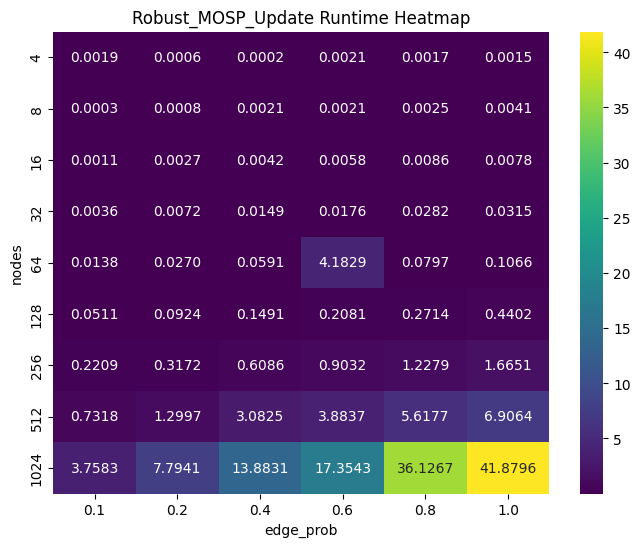

In [11]:
# nodes vs edge probablity
pivot = df2.pivot_table(
    values="runtime",
    index="nodes",
    columns="edge_prob",
    aggfunc=np.mean
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".4f",
    cmap="viridis"
)

plt.title("Robust_MOSP_Update Runtime Heatmap")
plt.show()


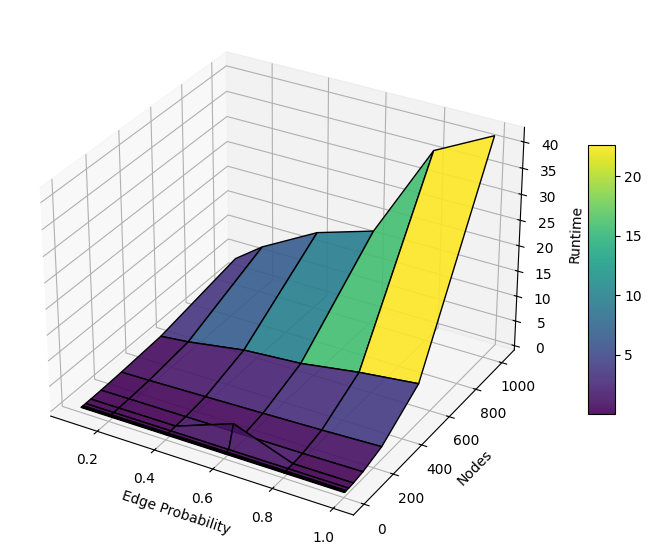

In [12]:
# 3D surface plot
from mpl_toolkits.mplot3d import Axes3D

nodes = pivot.index.values
edge_probs = pivot.columns.values

X, Y = np.meshgrid(edge_probs, nodes)
Z = pivot.values

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(
    X, Y, Z,
    cmap='viridis',
    edgecolor='k',
    alpha=0.9
)


ax.set_xlabel("Edge Probability")
ax.set_ylabel("Nodes")
ax.set_zlabel("Runtime")
fig.colorbar(surface, shrink=0.5, aspect=10)

plt.show()